# V54: Final Stable Strategy (Ai + Trend Override SMA 50) (LQ45)

Notebook ini adalah versi **Final & Stabil** dari strategi yang dikembangkan.
Tujuannya adalah memastikan hasil yang **Konsisten (Reproducible)** dengan mengunci faktor acak (Random Seed) pada algoritma seleksi aset (MIS) dan optimasi Markowitz.

### Strategi Juara (Challenger):
**AI + Trend Override (SMA 50)**: Menggunakan sinyal AI, tetapi "memaksa" tetap Invest (Risk ON) jika tren pasar sedang Bullish (Harga > SMA 50).

### Benchmark (Defender):
**Static Markowitz**: Selalu Invest (Risk ON) dengan seleksi aset MIS + Markowitz.

### Fee Control:
Semua strategi menggunakan Fee 0.25% per transaksi, Rebalancing 20 Hari, dan Turnover Buffer 5%.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import random
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- LOCK RANDOMNESS FOR STABILITY ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# --- 1. Load Data ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
# Reconstruct Market Index for Trend Calculation
market_index = (1 + market_return).cumprod() * 100

print(f"Data Loaded: {len(data)} rows")

Data Loaded: 712 rows


In [2]:
# --- 2. AI Training (Standard V47) ---
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [3]:
# --- 3. Core Logic: Stable Simulation ---

def get_mis_assets_stable(returns_window, correlation_threshold=0.4):
    # Standard MIS can be unstable. We try to make it stable by sorting nodes first.
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = sorted(returns_window.columns) # Sort for consistency
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    
    # nx.approximation.maximum_independent_set is heuristic but let's trust fixed seed + sorted graph
    # If needed, we can use a simpler greedy manual approach, but sticking to library for now.
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation_stable(test_dates, returns, ai_probs, threshold, market_idx, 
                          override_ma=None, # Only parameter needed. If None = No Override.
                          fee=0.0025, 
                          g_lookback=60, 
                          rebal_period=20, 
                          turnover_buffer=0.05):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {} 
    risk_status = False 
    
    days_since_rebal = 999
    
    # Calculate Moving Average for Trend Override check
    market_ma = None
    if override_ma:
        market_ma = market_idx.rolling(window=override_ma).mean()
    
    for i, date in enumerate(test_dates[:-1]):
        prev_risk_status = risk_status
        prob = ai_probs.loc[date]
        
        # 1. Base AI Signal
        ai_signal = False
        buffer = 0.05
        if not risk_status and prob > (threshold + buffer): ai_signal = True
        elif risk_status and prob < (threshold - buffer): ai_signal = False
        else: ai_signal = risk_status 
        
        # 2. Trend Override Logic
        final_signal = ai_signal
        
        if override_ma and market_ma is not None:
            try:
                current_price = market_idx.loc[date]
                ma_price = market_ma.loc[date]
                if not pd.isna(ma_price) and not pd.isna(current_price):
                    is_uptrend = (current_price > ma_price)
                    if ai_signal == False and is_uptrend:
                        final_signal = True # Force Hold
            except KeyError:
                pass 
        
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        
        # --- 3. Portfolio Management ---
        target_weights = current_weights.copy()
        
        if not risk_status:
            # Risk OFF
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            # Risk ON
            if regime_changed or days_since_rebal >= rebal_period:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                selected = get_mis_assets_stable(window_rets)
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                
                if regime_changed or turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
            
            days_since_rebal += 1

        # --- 4. Execution ---
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            new_weights_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    r_asset = r if not pd.isna(r) else 0
                    day_ret += w * r_asset
                    new_weights_drifted[asset] = w * (1 + r_asset)
                else:
                    new_weights_drifted[asset] = w
            
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

Running Static (Risk Always ON)...
Running AI + Trend Override (SMA 50)...


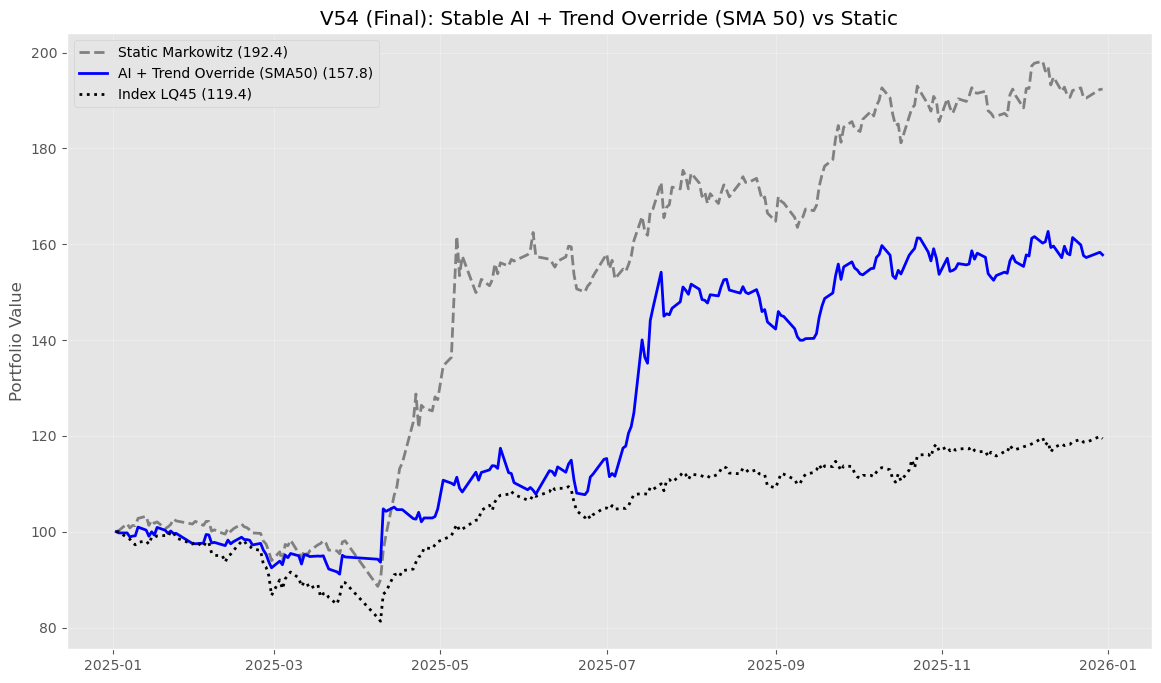


=== Performance ROI & Risk (V54 Stable) ===
                      Strategy   Return %   Max DD %
0             Static Markowitz  92.376866 -14.178491
1  AI + Trend Override (SMA50)  57.792246  -9.723880
2                   Index LQ45  19.435320 -18.695217


In [4]:
# --- 4. Run Scenarios (Stable) ---
test_dates = X_test.index
fee_rate = 0.0025

results = {}

# 1. Static (Benchmark Strategy)
print("Running Static (Risk Always ON)...")
static_probs = pd.Series(1.0, index=test_probs.index)
res_static = run_simulation_stable(test_dates, returns, static_probs, 0.5, market_index, 
                                   override_ma=None, fee=fee_rate)
results['Static Markowitz'] = res_static['Portfolio_Value']

# 2. Trend Override AI (SMA 50) - The Winner
print("Running AI + Trend Override (SMA 50)...")
res_trend50 = run_simulation_stable(test_dates, returns, test_probs, opt_t, market_index, 
                                    override_ma=50, fee=fee_rate)
results['AI + Trend Override (SMA50)'] = res_trend50['Portfolio_Value']

# 3. Benchmark Index
benchmark = market_index.reindex(res_static.index).ffill()
benchmark = benchmark / benchmark.iloc[0] * 100
results['Index LQ45'] = benchmark

# --- 5. Visualization ---
plt.figure(figsize=(14, 8))

colors = ['gray', 'blue', 'black']
styles = ['--', '-', ':']

for (name, series), color, style in zip(results.items(), colors, styles):
    plt.plot(series.index, series, label=f"{name} ({series.iloc[-1]:.1f})", color=color, linestyle=style, linewidth=2)

plt.title('V54 (Final): Stable AI + Trend Override (SMA 50) vs Static')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('v54_stable_final_results.png')
plt.show()

# Summary
summary = []
for name, series in results.items():
    total_ret = (series.iloc[-1] - 100)
    peak = series.cummax()
    dd = (series - peak) / peak
    max_dd = dd.min() * 100
    summary.append({'Strategy': name, 'Return %': total_ret, 'Max DD %': max_dd})

df_summary = pd.DataFrame(summary).sort_values('Return %', ascending=False)
print("\n=== Performance ROI & Risk (V54 Stable) ===")
print(df_summary.to_string())

df_results = pd.DataFrame(results)
df_results.to_excel('v54_stable_final_results.xlsx', index=False)